# Universal Cokriging插值法

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 固定參數
a = 1.7
c_o = 10
i_res = 4
gi_res = 2

# 解析度, 範圍
res = 20
ran = 2000
extent = [0, ran, 0, ran, 0, ran]
# extent = [0, 1000, 0, 1000, 0, 1000]

pattern = 4
using_GPU = True
using_pykeops = True

# 硬體加速上限
ORI_NUM = 8
INT_NUM = 45
LAY_NUM = 5
WEIGHT_NUM = 3 * ORI_NUM + INT_NUM - LAY_NUM + 3
NUM_PER_LAYER = int(INT_NUM / LAY_NUM)

if(pattern == 1):
    path_to_surface_points = "points_1.csv"
    path_to_orientations = "orientations_1.csv"
elif(pattern == 2):
    path_to_surface_points = "points_2.csv"
    path_to_orientations = "orientations_2.csv"
elif(pattern == 3):
    path_to_surface_points = "points_3.csv"
    path_to_orientations = "orientations_3.csv"
# elif(pattern == 4):
#     path_to_surface_points = "tutor_int.csv"
#     path_to_orientations = "tutor_ori.csv"
elif(pattern == 4):
    path_to_surface_points = "simulated_points.csv"
    path_to_orientations = "simulated_orientations.csv"

In [2]:
import os
from pyinstrument import Profiler
os.environ['DEFAULT_PYKEOPS'] = str(using_pykeops)
import time
import gempy as gp
from gempy_engine.core.backend_tensor import BackendTensor
from gempy_engine.config import AvailableBackends

BackendTensor._change_backend(
    engine_backend=AvailableBackends.PYTORCH,
    pykeops_enabled=using_pykeops,
    use_gpu=using_GPU
)

BackendTensor.use_gpu = using_GPU

print("\n--- 檢查結果 ---")
print("引擎後端:", BackendTensor.engine_backend)
print("GPU 是否開啟:", BackendTensor.use_gpu)
print("PyKeOps 是否開啟:", BackendTensor.pykeops_enabled)
print("底層偵測 PyKeOps 狀態:", BackendTensor.is_pykeops_enabled())
print("--------------------\n")

np.random.seed(5555)

geo_data: gp.data.GeoModel = gp.create_geomodel(
    project_name='kriging',
    extent=extent,
    resolution=[res, res, res],
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=path_to_orientations,
        path_to_surface_points=path_to_surface_points,
    )
)

geo_data.interpolation_options.mesh_extraction = False

# 建立分析器
profiler = Profiler()

# 開始紀錄
profiler.start()
t1 = time.perf_counter()
gp.compute_model(
    geo_data,
    engine_config=gp.data.GemPyEngineConfig(
        backend=gp.data.AvailableBackends.PYTORCH,
        use_gpu=using_GPU
    )
)
t2 = time.perf_counter()
Total = t2 - t1
print(f'Total time taken: {Total}')
profiler.stop()

# profiler.print()

/home/lab/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyKeOps is installed.
pytorch is installed.
Setting Backend To: AvailableBackends.numpy
Setting Backend To: AvailableBackends.PYTORCH

--- 檢查結果 ---
引擎後端: AvailableBackends.PYTORCH
GPU 是否開啟: True
PyKeOps 是否開啟: True
底層偵測 PyKeOps 狀態: True
--------------------

Setting Backend To: AvailableBackends.PYTORCH
GemPyEngineConfig(backend=<AvailableBackends.PYTORCH: 2>, use_gpu=True, dtype=None)
Final Iteration 365, Residual Norm: 2.2242158844384055e-06
Total time taken: 1.637967787000008


In [3]:
def get_function_time_from_profiler(frame, target_func_name):
    total_time = 0.0
    # 如果找到目標函數，就把時間加起來
    # (不遞迴它的子節點，避免重複計算它內部呼叫的函數時間)
    if frame.function == target_func_name:
        total_time += frame.time
    else:
        # 如果不是目標函數，就繼續往下找它的子節點
        for child in frame.children:
            total_time += get_function_time_from_profiler(child, target_func_name)
            
    return total_time

# 從 profiler 取得 root frame，並開始搜尋
# pyinstrument 將所有的分析資料儲存在 last_session 中
root_frame = profiler.last_session.root_frame()

# 將提取出的時間存成獨立變數
total_time = root_frame.time
eval_sys_eq_time = get_function_time_from_profiler(root_frame, '_evaluate_sys_eq')
weight_time = get_function_time_from_profiler(root_frame, '_solve_and_store_weights')
formation_time = get_function_time_from_profiler(root_frame, 'activate_formation_block')

print(f"成功從 pyinstrument 提取！")
print(f"總時間為: {total_time:.6f} 秒")
print(f"_evaluate_sys_eq 消耗時間為: {eval_sys_eq_time:.6f} 秒")
print(f"_solve_and_store_weights 消耗時間為: {weight_time:.6f} 秒")
print(f"activate_formation_block 消耗時間為: {formation_time:.6f} 秒")

成功從 pyinstrument 提取！
總時間為: 1.637675 秒
_evaluate_sys_eq 消耗時間為: 0.151551 秒
_solve_and_store_weights 消耗時間為: 1.305214 秒
activate_formation_block 消耗時間為: 0.042562 秒


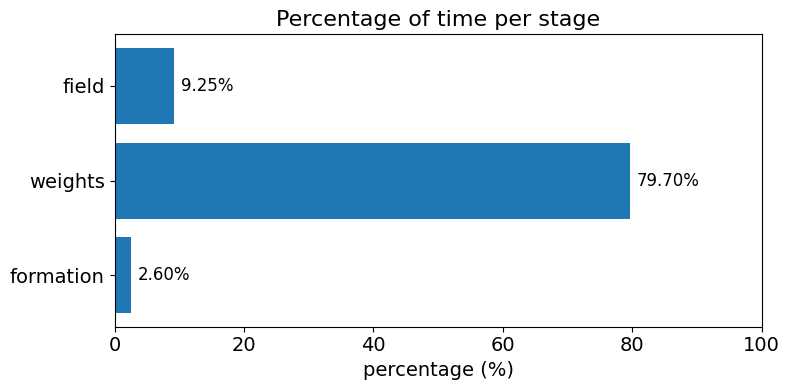

In [4]:
import matplotlib.pyplot as plt

stages = ['field', 'weights', 'formation']
percentages = [
    eval_sys_eq_time / total_time * 100, 
    weight_time / total_time * 100, 
    formation_time / total_time * 100
]

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

bars = ax.barh(stages, percentages, color='#1f77b4')

ax.invert_yaxis()

ax.set_title('Percentage of time per stage', fontsize=16)
ax.set_xlabel('percentage (%)', fontsize=14)
ax.set_xlim(0, 100)
ax.tick_params(axis='both', labelsize=14)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1.0,  # X 座標
        bar.get_y() + bar.get_height() / 2,  # Y 座標
        f'{width:.2f}%',
        ha='left',    
        va='center',  
        fontsize=12
    )

# 確保圖表元素不會被邊界裁切
plt.tight_layout()
# 顯示圖表
plt.show()

/home/lab/.local/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


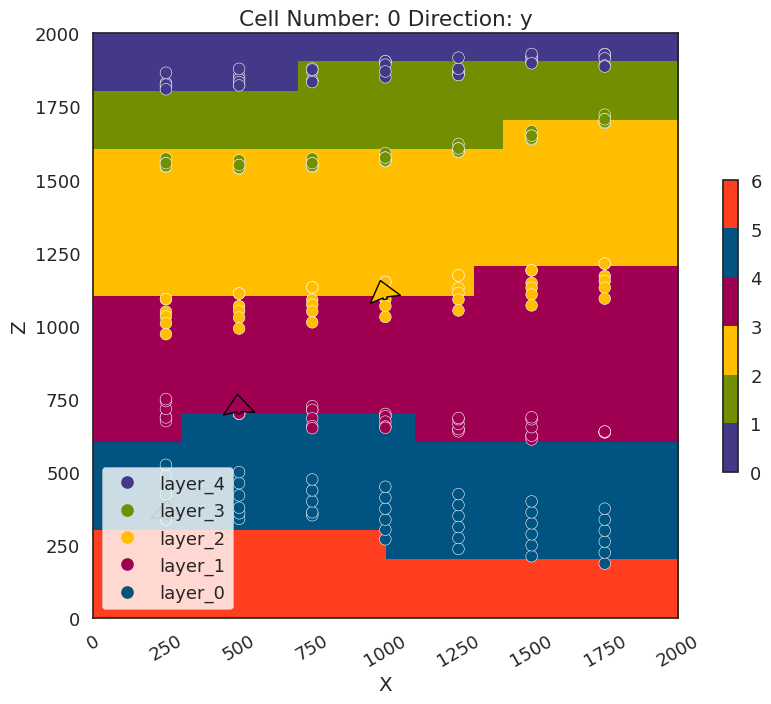

In [5]:
import gempy_viewer as gpv

plot = gpv.plot_2d(geo_data, show_lith=True, show_boundaries=False, direction= 'y', cell_number=0)

# 使用FPGA加速正規化部分

FPGA的overlay改為array.bit

In [6]:
np.set_printoptions(suppress=True, precision=6)

def _adjust_scale_to_limit_ratio(s, anisotropic_limit=np.array([1, 1, 1])):
    # Calculate the ratios
    ratios = [
        s[0] / s[1], s[0] / s[2],
        s[1] / s[0], s[1] / s[2],
        s[2] / s[0], s[2] / s[1]
    ]

    # Adjust the scales based on the index of the max ratio
    if ratios[0] > anisotropic_limit[0]:
        s[0] = s[1] * anisotropic_limit[0]
    if ratios[1] > anisotropic_limit[0]:
        s[0] = s[2] * anisotropic_limit[0]

    if ratios[2] > anisotropic_limit[1]:
        s[1] = s[0] * anisotropic_limit[1]
    if ratios[3] > anisotropic_limit[1]:
        s[1] = s[2] * anisotropic_limit[1]

    if ratios[4] > anisotropic_limit[2]:
        s[2] = s[0] * anisotropic_limit[2]
    if ratios[5] > anisotropic_limit[2]:
        s[2] = s[1] * anisotropic_limit[2]

    return s

In [7]:
import socket, struct

# 定義發送與接收的資料型別
SEND_DT = np.int64  # 64-bit (8 bytes)
RECV_DT = np.int16  # 16-bit (2 bytes)
SOCK_BUF_SIZE = 16 * 1024 * 1024  # 16MB Buffer

class PYNQClient:
    def __init__(self, host, port=8765):
        self.addr = (host, port)
        self.s = None
        self.hbuf = bytearray(8)
        self.hview = memoryview(self.hbuf)

    def connect(self):
        self.s = socket.create_connection(self.addr)
        self.s.setsockopt(socket.IPPROTO_TCP, socket.TCP_NODELAY, 1)
        self.s.setsockopt(socket.SOL_SOCKET, socket.SO_RCVBUF, SOCK_BUF_SIZE)
        self.s.setsockopt(socket.SOL_SOCKET, socket.SO_SNDBUF, SOCK_BUF_SIZE)

    def close(self):
        if self.s: self.s.close()

    def run(self, arr: np.ndarray) -> np.ndarray:
        # 確保發送資料格式正確
        if not arr.flags['C_CONTIGUOUS'] or arr.dtype != SEND_DT:
            arr = np.ascontiguousarray(arr, dtype=SEND_DT)
            
        nbytes = arr.nbytes
        
        # 1. 送出長度
        struct.pack_into("<Q", self.hbuf, 0, nbytes)
        self.s.sendall(self.hbuf)
        
        # 2. 送出 64-bit 資料
        self.s.sendall(arr)

        # 3. 接收回傳資料的總位元組數 (Bytes)
        self.s.recv_into(self.hview, 8, socket.MSG_WAITALL)
        r_nbytes = struct.unpack("<Q", self.hbuf)[0]

        # 4. 接收 16-bit 資料
        # 總 Bytes 除以 2 就是 16-bit 元素的數量
        out = np.empty(r_nbytes // 2, dtype=RECV_DT) 
        self.s.recv_into(out, r_nbytes, socket.MSG_WAITALL)
        
        return out

In [8]:
import pandas as pd

def build_points_data(interfaces_active, orientations_active):
    """
    自動進行補零(Zero-padding)與陣列組合
    interfaces_active: 每一層(Layer)有效點的二維陣列 (List of lists)
    orientations_active: 有效方向點的二維陣列
    """
    i_all_padded = []
    i_valid_only = []
    ref_points = []
    
    # 預設參考點，如果第一層就沒資料的防呆機制
    last_valid_ref = [0, 0, 0] 

    # 處理 Interfaces (共 5 層)
    for layer_idx in range(LAY_NUM):
        # 檢查該層是否有資料
        if layer_idx < len(interfaces_active) and interfaces_active[layer_idx]:
            layer_pts = interfaces_active[layer_idx]
            i_valid_only.extend(layer_pts)
            last_valid_ref = layer_pts[0]  # 記錄該層的第一個點作為參考點
        else:
            layer_pts = []
            
        # 將該層不足 7 個點的部分補 [0, 0, 0]
        padded_layer = layer_pts + [[0, 0, 0]] * (NUM_PER_LAYER - len(layer_pts))
        i_all_padded.extend(padded_layer)
        
        # 收集最後的 5 個參考點 (若當層為空，會自然重複上一次記錄的 last_valid_ref)
        ref_points.append(last_valid_ref)

    i__ = np.array(i_valid_only)
    i_ = np.array(i_all_padded) # 35個點

    # 處理 Orientations (最多 8 個)
    o__ = np.array(orientations_active)
    o_all_padded = orientations_active + [[0, 0, 0]] * (ORI_NUM - len(orientations_active))
    o_ = np.array(o_all_padded)

    return i__, i_, o__, o_, ref_points

def load_data_from_csv(points_file, orientations_file):
    """
    從 CSV 檔案自動讀取並轉換為 build_points_data 需要的 list 格式，
    並確保兩者都依照 formation 欄位排序。
    """
    # ==========================================
    # 1. 處理 Interfaces (讀取 points_X.csv)
    # ==========================================
    df_points = pd.read_csv(points_file)
    interfaces = []
    
    # 確保 CSV 中有 formation 欄位可供分層與排序
    if 'formation' in df_points.columns:
        # 找出所有獨立的層並排序 (例如: 'layer_0' -> 'layer_1' -> 'layer_2')
        layers = sorted(df_points['formation'].unique())
        for layer in layers:
            # 取出該層的 X, Y, Z 並轉成 Python 原生 List
            pts = df_points[df_points['formation'] == layer][['X', 'Y', 'Z']].values.tolist()
            interfaces.append(pts)
    else:
        # 若沒有 formation 欄位，就全部當成第一層
        interfaces.append(df_points[['X', 'Y', 'Z']].values.tolist())

    # ==========================================
    # 2. 處理 Orientations (讀取 orientations_X.csv)
    # ==========================================
    df_ori = pd.read_csv(orientations_file)
    
    # 確保 CSV 中有 formation 欄位可供排序
    if 'formation' in df_ori.columns:
        # 依照 formation 欄位進行排序，確保跟 interfaces 的順序邏輯一致
        df_ori = df_ori.sort_values(by='formation')
        
    # 取出排序後的 X, Y, Z (這會是一個平坦的二維陣列，也就是你原本要的格式)
    orientations = df_ori[['X', 'Y', 'Z']].values.tolist()

    return interfaces, orientations

# ==========================================
# 實際使用：直接讀取對應的 CSV 檔案
# ==========================================

try:
    # 從 CSV 自動載入資料
    interfaces, orientations = load_data_from_csv(path_to_surface_points, path_to_orientations)
    
    # 丟入原本的處理函數
    i__, i_, o__, o_ , ref_points = build_points_data(interfaces, orientations)
    
    print(f"成功讀取 Pattern {pattern} 的資料！")
    print(f"有效點 (i__) 形狀: {i__.shape}")
    print(f"補零後點 (i_) 形狀: {i_.shape}")
    print(f"有效方向 (o__) 形狀: {o__.shape}")
    print(f"補零後方向 (o_) 形狀: {o_.shape}")
    print(f"參考點 (ref_points) 形狀: {len(ref_points)}")

except FileNotFoundError as e:
    print(f"找不到檔案！請確定 {path_to_surface_points} 與 {path_to_orientations} 是否放在同一個資料夾內。")

成功讀取 Pattern 4 的資料！
有效點 (i__) 形狀: (245, 3)
補零後點 (i_) 形狀: (245, 3)
有效方向 (o__) 形狀: (5, 3)
補零後方向 (o_) 形狀: (8, 3)
參考點 (ref_points) 形狀: 5


In [9]:
# 假設前面已經執行了 load_data_from_csv() 取得了 interfaces 和 orientations
# 例如: interfaces, orientations = load_data_from_csv(points_filename, orientations_filename)

# 1. 取得方向點總數
ORI_NUM_input = len(orientations)

# 2. 取得有效層數 (interfaces 裡面有幾個 sub-list)
LAY_NUM_input = len(interfaces)

# 3. 取得各層的點數 (計算每一層有幾個點)
# 先用迴圈算出每一層的點數，例如 [7, 7, 7, 7, 7] 或 [3, 3]
num_points_per_layer = [len(layer) for layer in interfaces]

# 為了防止層數不到 5 層 (例如只有 2 層)，我們在後面補上足夠的 0，並只取前 5 個
num_points_per_layer = (num_points_per_layer + [0] * 5)[:5]

NUM_LAYER_1_input = num_points_per_layer[0]
NUM_LAYER_2_input = num_points_per_layer[1]
NUM_LAYER_3_input = num_points_per_layer[2]
NUM_LAYER_4_input = num_points_per_layer[3]
NUM_LAYER_5_input = num_points_per_layer[4]

# 4. 取得全部介面點總數
INT_NUM_input = sum(num_points_per_layer)


# ==========================
# 檢查結果印出 (確認是否和以前一樣)
# ==========================
print("\n--- 自動計算變數結果 ---")
print(f"LAY_NUM_input = {LAY_NUM_input}")
print(f"NUM_LAYER_1_input = {NUM_LAYER_1_input}")
print(f"NUM_LAYER_2_input = {NUM_LAYER_2_input}")
print(f"NUM_LAYER_3_input = {NUM_LAYER_3_input}")
print(f"NUM_LAYER_4_input = {NUM_LAYER_4_input}")
print(f"NUM_LAYER_5_input = {NUM_LAYER_5_input}")
print(f"ORI_NUM_input = {ORI_NUM_input}")
print(f"INT_NUM_input = {INT_NUM_input}")
print("------------------------\n")


--- 自動計算變數結果 ---
LAY_NUM_input = 5
NUM_LAYER_1_input = 49
NUM_LAYER_2_input = 49
NUM_LAYER_3_input = 49
NUM_LAYER_4_input = 49
NUM_LAYER_5_input = 49
ORI_NUM_input = 5
INT_NUM_input = 245
------------------------



In [10]:
io = np.vstack([i__,o__])
SCALE = [(np.max(io[:,0]) - np.min(io[:,0])) * 2, (np.max(io[:,1]) - np.min(io[:,1])) * 2, (np.max(io[:,2]) - np.min(io[:,2])) * 2]
s = 1 / np.array(SCALE)
s = np.round(_adjust_scale_to_limit_ratio(s) * 2**32)
X0 = (np.max(io[:,0]) + np.min(io[:,0])) / 2
Y0 = (np.max(io[:,1]) + np.min(io[:,1])) / 2
Z0 = (np.max(io[:,2]) + np.min(io[:,2])) / 2
x = round(-X0 * s[0])
y = round(-Y0 * s[1])
z = round(-Z0 * s[2])
S = np.eye(3,dtype=np.uint32) * s
T = np.array([[x], [y], [z]])
SRT = np.hstack([S, T])
SRT = SRT.ravel()

In [11]:
print(S)
print(T)
print(SRT)

[[1232811.       0.       0.]
 [      0. 1232811.       0.]
 [      0.       0. 1232811.]]
[[-1232811000]
 [-1232811000]
 [-1304893459]]
[ 1.232811e+06  0.000000e+00  0.000000e+00 -1.232811e+09  0.000000e+00
  1.232811e+06  0.000000e+00 -1.232811e+09  0.000000e+00  0.000000e+00
  1.232811e+06 -1.304893e+09]


In [12]:
o_ = np.hstack([o_, np.ones((o_.shape[0],1))])
i_ = np.hstack([i_, np.ones((i_.shape[0],1))])
ref_points = np.hstack([ref_points, np.ones((len(ref_points),1))])

In [13]:
# 1. 先定義每個軸的刻度 (Ticks)
# ticks = np.arange(ran / res / 2, ran, ran / res)

ticks_x = np.arange(extent[0] + extent[1] / res / 2, extent[1], extent[1] / res)
ticks_y = np.arange(extent[2] + extent[3] / res / 2, extent[3], extent[3] / res)
ticks_z = np.arange(extent[4] + extent[5] / res / 2, extent[5], extent[5] / res)

# 2. 使用 meshgrid 生成所有組合的座標點
xx_grid, yy_grid, zz_grid = np.meshgrid(ticks_x, ticks_y, ticks_z, indexing='ij')

# xx_grid, yy_grid, zz_grid = np.meshgrid(ticks, ticks, ticks, indexing='ij')

# 3. 將多維網格展平回一維陣列，以便進行後續的 vector 計算
xx_ = xx_grid.ravel()
yy_ = yy_grid.ravel()
zz_ = zz_grid.ravel()

# 構造 [x, y, z, 1, x, y, z, 1, ...]
ones = np.ones_like(xx_)
# 堆疊成 (N, 4) 的形狀: [[x0, y0, z0, 1], [x1, y1, z1, 1], ...]
stacked = np.column_stack((xx_, yy_, zz_, ones))
vector = stacked.ravel() # 展平成一維

print("前 12 個數字 (3組座標):")
print(vector[:100])

前 12 個數字 (3組座標):
[  50.   50.   50.    1.   50.   50.  150.    1.   50.   50.  250.    1.
   50.   50.  350.    1.   50.   50.  450.    1.   50.   50.  550.    1.
   50.   50.  650.    1.   50.   50.  750.    1.   50.   50.  850.    1.
   50.   50.  950.    1.   50.   50. 1050.    1.   50.   50. 1150.    1.
   50.   50. 1250.    1.   50.   50. 1350.    1.   50.   50. 1450.    1.
   50.   50. 1550.    1.   50.   50. 1650.    1.   50.   50. 1750.    1.
   50.   50. 1850.    1.   50.   50. 1950.    1.   50.  150.   50.    1.
   50.  150.  150.    1.   50.  150.  250.    1.   50.  150.  350.    1.
   50.  150.  450.    1.]


In [14]:
import math

def package():
    # ==========================================
    # 0. 預處理 (確保相關變數與設定已存在)
    # ==========================================
    np.set_printoptions(suppress=True, precision=6)
    resolution = np.array([res**3])

    w_np = geo_data.solutions.debug_input_data['weights'].flatten().numpy()

    o_pts = o_.reshape(-1, 4) 
    i_pts = i_.reshape(-1, 4)
    vector_pt = vector.reshape(-1, 4) 

    # ==========================================
    # 1. 定義硬體與計算參數 (嚴格遵守逐層容量限制)
    # ==========================================
    # HW_WTS_PER_LAY 是該層的「新點(帶權重)」數量
    HW_WTS_PER_LAY = (INT_NUM - LAY_NUM) // LAY_NUM  
    # HW_PTS_PER_LAY 是該層的「總點數 (新點 + 1個參考點)」數量
    HW_PTS_PER_LAY = INT_NUM // LAY_NUM

    # IN_LAY_CAP = NUM_LAYER_1_input - 1   

    layer_inputs =[
        NUM_LAYER_1_input, NUM_LAYER_2_input, NUM_LAYER_3_input, 
        NUM_LAYER_4_input, NUM_LAYER_5_input
    ]

    # ==========================================
    # 2. Step A: 逐層提取有效數據
    # ==========================================
    ori_vals =[]
    for i in range(3):
        s_start = i * ORI_NUM_input
        ori_vals.append(w_np[s_start : s_start + ORI_NUM_input] * c_o * gi_res)

    layer_wts = []
    layer_pts =[]
    pt_offset = 0

    valid_wts_len_pre = 0
    for i in range(LAY_NUM_input):
        valid_wts_len = layer_inputs[i] - 1
        if i > 0:
            valid_wts_len_pre += layer_inputs[i - 1] - 1
        s_start = 3 * ORI_NUM_input + valid_wts_len_pre
        layer_wts.append(w_np[s_start : s_start + valid_wts_len] * c_o * i_res)
        # print(s_start, s_start + valid_wts_len)
        
        valid_pts_len = layer_inputs[i] if layer_inputs[i] > HW_PTS_PER_LAY else HW_PTS_PER_LAY
        
        layer_pts.append(i_pts[pt_offset : pt_offset + valid_pts_len])
        pt_offset += valid_pts_len

    coord_vals = w_np[3 * ORI_NUM_input + INT_NUM_input - LAY_NUM_input : 
                    3 * ORI_NUM_input + INT_NUM_input - LAY_NUM_input + 3] * gi_res

    # ==========================================
    # 3. Step B: 動態計算總共需要幾次 Pass
    # ==========================================
    passes_needed = math.ceil(ORI_NUM_input / ORI_NUM)

    for i in range(LAY_NUM_input):
        # 因為每次 Pass 處理的「新點(需計算的點)」數量等於 HW_WTS_PER_LAY
        # 所以直接用權重長度來判斷總共需要幾次 Pass 即可
        if len(layer_wts[i]) > 0:
            passes_needed = max(passes_needed, math.ceil(len(layer_wts[i]) / HW_WTS_PER_LAY))

    passes_needed = max(1, passes_needed)

    # ==========================================
    # 4. Step C: 執行多輪封裝 (包含參考點保留機制)
    # ==========================================
    all_packed_results =[] 

    for p in range(passes_needed):
        weight = np.zeros(WEIGHT_NUM)
        
        # ------------------------------------
        # (a) 填入方向點
        # ------------------------------------
        o_pass = np.zeros((ORI_NUM, 4)) 
        o_chunk = o_pts[p * ORI_NUM : (p + 1) * ORI_NUM]
        if len(o_chunk) > 0:
            o_pass[:len(o_chunk)] = o_chunk
        
        for i in range(3):
            t_start = i * ORI_NUM 
            chunk = ori_vals[i][p * ORI_NUM : (p + 1) * ORI_NUM]
            if len(chunk) > 0:
                weight[t_start : t_start + len(chunk)] = chunk
            
        # ------------------------------------
        # (b) 填入表面層權重與座標 (⭐核心修正點)
        # ------------------------------------
        i_pass = np.zeros((HW_PTS_PER_LAY * LAY_NUM, 4)) 
        
        for i in range(LAY_NUM_input):
            # 【權重處理】：因為參考點沒有對應的權重(或權重不在此輸入)，所以權重依然依序提取即可
            t_w_start = 3 * ORI_NUM + i * HW_WTS_PER_LAY
            w_chunk = layer_wts[i][p * HW_WTS_PER_LAY : (p + 1) * HW_WTS_PER_LAY]
            # print(w_chunk*2**16)
            if len(w_chunk) > 0:
                weight[t_w_start : t_w_start + len(w_chunk)] = w_chunk
                
            # 【座標處理】：加入保留第一點 (參考點) 邏輯
            t_p_start = i * HW_PTS_PER_LAY
            
            if p == 0:
                # 第一次計算：直接拿取該層前 HW_PTS_PER_LAY 個點
                p_chunk = layer_pts[i][0 : HW_PTS_PER_LAY]
                # print(p_chunk)
            else:
                # 第二次計算以上：
                # 因為第 0 個點已被保留，接下來的「新點」從 index 1 開始算
                # 每次抓取數量等同於權重數量 HW_WTS_PER_LAY
                start_idx = p * HW_WTS_PER_LAY + 1
                end_idx = (p + 1) * HW_WTS_PER_LAY + 1
                next_pts = layer_pts[i][start_idx : end_idx]
                
                if len(next_pts) > 0:
                    # 關鍵邏輯：將原本的「第一個點(參考點)」與「新抓出來的多餘點」垂直堆疊(vstack)
                    # 確保參考點永遠在當次計算的第 0 個位置，多餘點從第 1 個位置開始
                    p_chunk = np.vstack((layer_pts[i][0:1], next_pts))
                else:
                    p_chunk = np.empty((0, 4))

            # print(p_chunk)
                    
            # 寫入硬體座標區段
            if len(p_chunk) > 0:
                i_pass[t_p_start : t_p_start + len(p_chunk)] = p_chunk
                
        # ------------------------------------
        # (c) 計算點權重 (僅在第一次填入)
        # ------------------------------------
        if p == 0:
            t_idx = 3 * ORI_NUM + INT_NUM - LAY_NUM
            weight[t_idx : t_idx + 3] = coord_vals
        
        weight_fixed = np.round(weight * 2**16).astype(np.int64)
        # print(weight_fixed)

        # ------------------------------------
        # (d) 座標封裝與位元運算
        # ------------------------------------
        # 這裡保留您加入的 ref_points
        input_array = np.round(np.concatenate((o_pass.ravel(), i_pass.ravel(), ref_points.ravel(), vector_pt.ravel())) * 32)
        # print(i_pass[:200])
            
        groups = input_array.reshape(-1, 4).astype(np.int64)
        
        packed_u64_coords = (groups[:, 3] << 48) | (groups[:, 2] << 32) | (groups[:, 1] << 16) | groups[:, 0]
        packed_u64_coords = np.concatenate((SRT, packed_u64_coords)).astype(np.int64)
        # print(packed_u64_coords[:100])
        
        # ------------------------------------
        # (e) 最終大合併
        # ------------------------------------
        packed_u64_final = np.concatenate((resolution, weight_fixed, packed_u64_coords)).astype(np.int64)
        all_packed_results.append(packed_u64_final)
        # print(packed_u64_final[0:150])
    return all_packed_results, passes_needed

In [15]:
all_packed_results, passes_needed = package()
passes_needed

6

In [16]:
cli = PYNQClient("192.168.3.1")
cli.connect()
t1 = time.perf_counter()
PL_result_list = np.zeros((passes_needed, res**3 + 5), dtype=np.int16)
for i in range(passes_needed):
    PL_result_list[i] = cli.run(all_packed_results[i])
PL_result = np.sum(PL_result_list, axis=0, dtype=np.int16)
t2 = time.perf_counter()
print(t2 - t1)

0.03293262900000116


In [17]:
def labelize(PL_result):
    layers = np.zeros(LAY_NUM)
    layers[0:LAY_NUM_input] = np.array(geo_data.solutions.raw_arrays.scalar_field_at_surface_points).ravel()*16384
    layers[0:LAY_NUM_input].sort()
    # layers = PL_result[0:LAY_NUM_input]
    layers[LAY_NUM_input:LAY_NUM] = 2**15-1
    field  = PL_result[5:]
    conditions = [
        field <= layers[0],
        field <= layers[1],
        field <= layers[2],
        field <= layers[3],
        field <= layers[4]
    ]
    
    # 定義對應的 Label 數值
    choices = [6, 5, 4, 3, 2]
    
    # np.select 會依序檢查 conditions，若為 True 就套用 choices 的值。
    # 如果全部都不符合 (亦即大於所有層)，就套用 default 值。
    labels_PL = np.select(conditions, choices, default=6 - LAY_NUM_input)

    print(layers)

    return labels_PL

In [18]:
labels_PL = labelize(PL_result)
labels_PL[labels_PL < (6 - LAY_NUM_input)] = 6 - LAY_NUM_input
labels_PL = labels_PL - (5 - LAY_NUM_input) # 5 是 LAY_NUM，LAY_NUM_input 是輸入的 layer 數量

[-2380.90906   -497.778231  2102.344353  5770.896468  7211.729384]


In [19]:
idx_PL = np.flatnonzero(labels_PL.ravel() - geo_data.solutions.raw_arrays.lith_block)
print(f'number of PL errors: {idx_PL.size}\nfall at point: {idx_PL}')
print(f'PL labels at error points: {labels_PL.ravel()[idx_PL][0:100]}')
print(labels_PL.ravel()[idx_PL] - geo_data.solutions.raw_arrays.lith_block[idx_PL])

idx_PL.size / res**3 * 100

number of PL errors: 66
fall at point: [   6  315  367  555  638  658  667  687  806 1067 1115 1315 1475 1495
 1663 1790 1878 2043 2095 2118 2218 2230 2295 2315 2515 2518 2598 2650
 2675 2738 2799 2935 2978 3086 3106 3138 3375 3395 3435 3478 3518 3599
 3884 3886 4111 4163 4258 5124 5530 5682 5786 5936 6136 6176 6196 6236
 6606 6746 6922 7266 7286 7431 7557 7601 7646 7966]
PL labels at error points: [5 3 5 3 1 1 5 4 5 5 2 2 3 2 6 4 1 6 2 1 1 4 3 2 3 2 1 4 3 2 2 3 1 4 4 1 2
 3 2 1 2 2 6 5 4 6 1 6 3 6 5 3 2 2 2 2 5 4 6 5 5 3 2 5 5 4]
[ 1  1  1  1 -1 -1  1 -1  1  1 -1 -1  1 -1  1  1 -1  1 -1 -1 -1  1  1 -1
  1  1 -1  1  1  1  1  1 -1 -1 -1 -1 -1  1 -1 -1  1  1  1  1  1  1 -1  1
 -1  1  1  1 -1 -1 -1 -1  1 -1  1  1  1 -1 -1 -1  1 -1]


0.8250000000000001

In [20]:
raise Exception("執行已在此手動停止，後續 Cell 將不會執行。")

Exception: 執行已在此手動停止，後續 Cell 將不會執行。

Setting Backend To: AvailableBackends.PYTORCH
GemPyEngineConfig(backend=<AvailableBackends.PYTORCH: 2>, use_gpu=True, dtype=None)
Setting Backend To: AvailableBackends.PYTORCH
GemPyEngineConfig(backend=<AvailableBackends.PYTORCH: 2>, use_gpu=True, dtype=None)
PC_time: 0.01200321199999621
[-2380.90906   -497.778231  2102.344353  5770.896468  7211.729384]
speedup: 0.5034850508096924
idx_PL.size: 10
percentage of PL errors: 1.0
----------------------------------------------------------------
Setting Backend To: AvailableBackends.PYTORCH
GemPyEngineConfig(backend=<AvailableBackends.PYTORCH: 2>, use_gpu=True, dtype=None)
PC_time: 0.013372623999998723
[-2380.90906   -497.778231  2102.344353  5770.896468  7211.729384]
speedup: 0.3562890597159734
idx_PL.size: 66
percentage of PL errors: 0.8250000000000001
----------------------------------------------------------------
Setting Backend To: AvailableBackends.PYTORCH
GemPyEngineConfig(backend=<AvailableBackends.PYTORCH: 2>, use_gpu=True, dtype=No

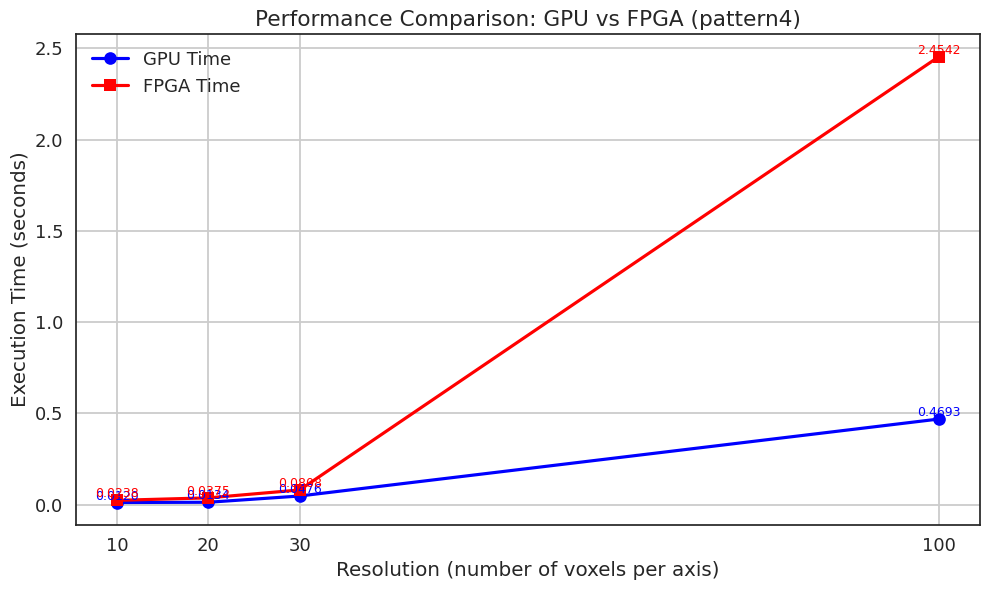

In [24]:
import matplotlib.pyplot as plt

# 暖機
geo_data: gp.data.GeoModel = gp.create_geomodel(
    project_name='kriging',
    extent=[0, 1000, 0, 1000, 0, 1000],
    resolution=[40, 40, 40],
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=path_to_orientations,
        path_to_surface_points=path_to_surface_points,
    )
)
geo_data.interpolation_options.mesh_extraction = False
gp.compute_model(geo_data,
                 engine_config=gp.data.GemPyEngineConfig(
                 backend=gp.data.AvailableBackends.PYTORCH,
                 use_gpu=using_GPU)
)

resolutions = [10, 20, 30, 100]
pc_times_list = []
pl_times_list = []
for res in resolutions:
    geo_data: gp.data.GeoModel = gp.create_geomodel(
        project_name='kriging',
        extent=[0, ran, 0, ran, 0, ran],
        resolution=[res, res, res],
        importer_helper=gp.data.ImporterHelper(
            path_to_orientations=path_to_orientations,
            path_to_surface_points=path_to_surface_points,
        )
    )
    geo_data.interpolation_options.mesh_extraction = False
    # 建立分析器
    profiler = Profiler()

    # 開始紀錄
    profiler.start()
    gp.compute_model(geo_data,
                     engine_config=gp.data.GemPyEngineConfig(
                     backend=gp.data.AvailableBackends.PYTORCH,
                     use_gpu=using_GPU)
    )
    profiler.stop()
    root_frame = profiler.last_session.root_frame()
    eval_sys_eq_time = get_function_time_from_profiler(root_frame, '_evaluate_sys_eq')

    print(f'PC_time: {eval_sys_eq_time}')
    pc_times_list.append(eval_sys_eq_time)

    t1 = time.perf_counter()
    io = np.vstack([i__,o__])
    SCALE = [(np.max(io[:,0]) - np.min(io[:,0])) * 2, (np.max(io[:,1]) - np.min(io[:,1])) * 2, (np.max(io[:,2]) - np.min(io[:,2])) * 2]
    s = 1 / np.array(SCALE)
    s = np.round(_adjust_scale_to_limit_ratio(s) * 2**32)
    X0 = (np.max(io[:,0]) + np.min(io[:,0])) / 2
    Y0 = (np.max(io[:,1]) + np.min(io[:,1])) / 2
    Z0 = (np.max(io[:,2]) + np.min(io[:,2])) / 2
    x = round(-X0 * s[0])
    y = round(-Y0 * s[1])
    z = round(-Z0 * s[2])
    S = np.eye(3,dtype=np.uint32) * s
    T = np.array([[x], [y], [z]])
    SRT = np.hstack([S, T])
    SRT = SRT.ravel()

    ticks_x = np.arange(extent[0] + extent[1] / res / 2, extent[1], extent[1] / res)
    ticks_y = np.arange(extent[2] + extent[3] / res / 2, extent[3], extent[3] / res)
    ticks_z = np.arange(extent[4] + extent[5] / res / 2, extent[5], extent[5] / res)
    xx_grid, yy_grid, zz_grid = np.meshgrid(ticks_x, ticks_y, ticks_z, indexing='ij')
    xx_ = xx_grid.ravel()
    yy_ = yy_grid.ravel()
    zz_ = zz_grid.ravel()
    ones = np.ones_like(xx_)
    stacked = np.column_stack((xx_, yy_, zz_, ones))
    vector = stacked.ravel() # 展平成一維

    all_packed_results, passes_needed = package()

    PL_result_list = np.zeros((passes_needed, res**3 + 5), dtype=np.int16)
    for i in range(passes_needed):
        PL_result_list[i] = cli.run(all_packed_results[i])
    PL_result = np.sum(PL_result_list, axis=0, dtype=np.int16)

    labels_PL = labelize(PL_result)
    labels_PL[labels_PL < (6 - LAY_NUM_input)] = 6 - LAY_NUM_input
    labels_PL = labels_PL - (5 - LAY_NUM_input) # 5 是 LAY_NUM，LAY_NUM_input 是輸入的 layer 數量
    t2 = time.perf_counter()
    PL_time = t2 - t1
    pl_times_list.append(PL_time)
    print(f'speedup: {eval_sys_eq_time / PL_time}')
    idx_PL = np.flatnonzero(labels_PL.ravel() - geo_data.solutions.raw_arrays.lith_block)
    print(f'idx_PL.size: {idx_PL.size}')
    print(f'percentage of PL errors: {idx_PL.size / res**3 * 100}')
    print('----------------------------------------------------------------')

plt.figure(figsize=(10, 6))

# 繪製 PC_time 折線
plt.plot(resolutions, pc_times_list, marker='o', linestyle='-', color='blue', label='GPU Time')
# 標示 PC 數值
for x, y in zip(resolutions, pc_times_list):
    plt.text(x, y, f'{y:.4f}', ha='center', va='bottom', fontsize=9, color='blue')

# 繪製 PL_time 折線
plt.plot(resolutions, pl_times_list, marker='s', linestyle='-', color='red', label='FPGA Time')
# 標示 PL 數值
for x, y in zip(resolutions, pl_times_list):
    plt.text(x, y, f'{y:.4f}', ha='center', va='bottom', fontsize=9, color='red')

# 設定圖表標籤與標題
plt.xlabel('Resolution (number of voxels per axis)')
plt.ylabel('Execution Time (seconds)')
plt.title(f'Performance Comparison: GPU vs FPGA (pattern{pattern})')
plt.legend()       # 顯示圖例
plt.grid(True)     # 顯示網格
plt.xticks(resolutions) # 強制 X 軸刻度顯示這幾個特定的 resolution

# 顯示或儲存圖片
plt.tight_layout()
plt.show()

In [ ]:
raise Exception("執行已在此手動停止，後續 Cell 將不會執行。")

# 效能測試

In [ ]:
import time
import threading
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import pynvml

%matplotlib inline

# ==========================================
# 1. 定義背景監控的變數與函數
# ==========================================
timestamps = []
power_gpu = []
stop_flag = False
power_limit_w = 50.0

def monitor_gpu_power():
    global timestamps, power_gpu, stop_flag, power_limit_w
    
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)

    start_time = time.time()
    
    while not stop_flag:
        current_time = time.time() - start_time
        power_w = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0
        
        timestamps.append(current_time)
        power_gpu.append(power_w)
        
        time.sleep(0.1) 
        
    pynvml.nvmlShutdown()

# ==========================================
# 2. 啟動背景監測 (記錄整體起始時間 t0)
# ==========================================
print("啟動 GPU 背景監測執行緒...")
stop_flag = False
timestamps.clear()
power_gpu.clear()

t0 = time.time()  # 整個測量過程的起始時間
monitor_thread = threading.Thread(target=monitor_gpu_power)
monitor_thread.start()

# ==========================================
# 3. 測量計算前的 IDLE 狀態 (等候 2 秒)
# ==========================================
print("測量初始 IDLE 狀態 (2 秒)...")
time.sleep(2.0)

# ==========================================
# 4. 執行主要計算任務 (主執行緒)
# ==========================================
t_start_compute = time.time() - t0  # 記錄計算開始的相對時間
print("開始執行 GemPy 模型計算...")

for i in range(5):
    print(f"  -> 正在計算第 {i+1}/5 圈...")
    # 你的實際運算
    gp.compute_model(geo_data,
                     engine_config=gp.data.GemPyEngineConfig(
                         backend=gp.data.AvailableBackends.PYTORCH,
                         use_gpu=True)
    )

t_end_compute = time.time() - t0  # 記錄計算結束的相對時間
print(f"✅ 計算完成！純運算耗時: {t_end_compute - t_start_compute:.2f} 秒")

# ==========================================
# 5. 測量計算後的 IDLE 狀態 (等候 2 秒)
# ==========================================
print("測量結束後 IDLE 狀態 (2 秒)...")
time.sleep(2.0)

# ==========================================
# 6. 停止監測並繪製圖表
# ==========================================
stop_flag = True
monitor_thread.join()
print("GPU 監測已結束，準備繪製圖表...\n")

if len(timestamps) > 0:
    max_gpu_power = max(power_gpu)
    
    # === 新增計算與列印平均功率 ===
    avg_gpu_power = sum(power_gpu) / len(power_gpu)
    print(f"GPU 平均功率: {avg_gpu_power:.2f} W")
    
    plt.figure(figsize=(10, 5), dpi=100)
    plt.plot(timestamps, power_gpu, 
             label=f'GPU Power [Max: {max_gpu_power:.2f} W]', 
             color='#2ca02c', linewidth=2)

    plt.title("GPU Power", fontsize=14, fontweight='bold')
    plt.xlabel("Time (Seconds)", fontsize=12)
    plt.ylabel("Power (Watts)", fontsize=12)

    plt.ylim(0, power_limit_w)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 警告：沒有收集到任何資料！")

In [ ]:
import time
# 讓FPGA一直計算方便記錄功耗
t1 = time.perf_counter()
for i in range(50):
    PL_result1 = cli.run(packed_u64)
    time.sleep(0.001)
t2 = time.perf_counter()
print(t2 - t1)

# 模型渲染

/home/lab/.local/lib/python3.10/site-packages/gempy_viewer/API/_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


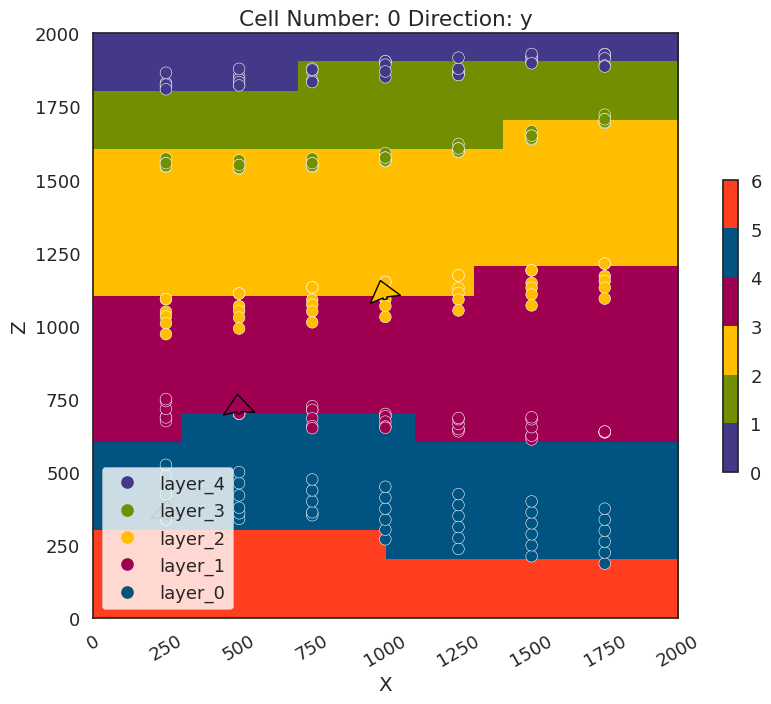

In [21]:
plot = gpv.plot_2d(geo_data, show_lith=True, show_boundaries=False, direction= 'y', cell_number=0)

In [ ]:
gpv.plot_3d(geo_data, show_surfaces=False, image=False, show_data=False)

# 替換為labels後渲染

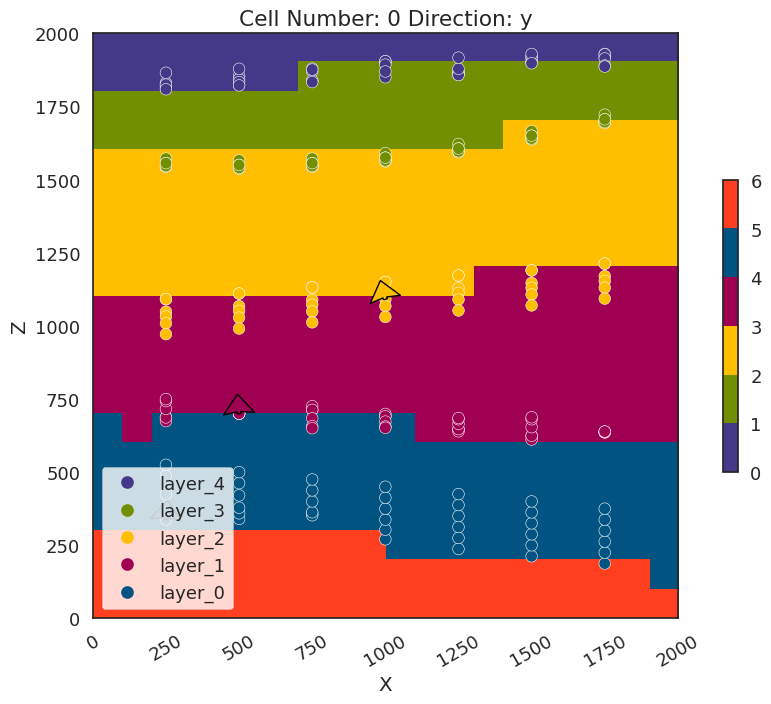

In [22]:
geo_data.solutions.raw_arrays.lith_block = labels_PL.ravel()
plot = gpv.plot_2d(geo_data, show_lith=True, show_boundaries=False, direction= 'y', cell_number=0)

In [ ]:
plot = gpv.plot_3d(geo_data, show_lith=True, show_boundaries=False, direction= 'y', cell_number=0)